# Detección de Shoplifting con SlowFast (R50)

Notebook **comparable** con el de VideoMAE: usa los **mismos datasets**, el **mismo split** (seed 42), y las **mismas métricas**. Lo único que cambia es la arquitectura.

**Arquitectura SlowFast:**
- **Slow pathway**: pocos frames, captura semántica espacial (qué hay en la escena)
- **Fast pathway**: muchos frames, captura dinámica temporal (cómo se mueve)
- Las dos ramas se fusionan con *lateral connections*

**Objetivo del experimento:** comparar accuracy contra VideoMAE (86.27%) sobre el mismo conjunto de test.


## Instalación de dependencias

In [ ]:
!pip install torch torchvision decord scikit-learn seaborn tqdm matplotlib
!pip install pytorchvideo fvcore iopath

---
# PARTE 1 — Entrenamiento del Modelo SlowFast

Se utilizan los **mismos 2 datasets** que el experimento de VideoMAE:
- **Dataset 1** (Mendeley - MNNIT Allahabad): 90 normal, 92 shoplifting
- **Dataset 2** (Kaggle): 70 normal, 86 shoplifting
- **Total combinado**: 160 normal + 178 shoplifting = **338 videos**

El modelo base es **SlowFast R50** pre-entrenado en Kinetics-400. Se le hace fine-tuning reemplazando la cabeza de clasificación de 400 clases por 2 (Normal / Shoplifting).

**Por cada video se extraen 32 frames** (fast pathway). De ahí, por submuestreo cada 4 frames, se generan los **8 frames del slow pathway**.

El split es **idéntico** al de VideoMAE (`seed=42`, `test_size=0.30`, `stratify`):
- **70%** entrenamiento (236 videos)
- **15%** validación (51 videos)
- **15%** test (51 videos)


In [3]:
import os
import glob
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
import decord
import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    'num_frames_fast': 32,
    'alpha'          : 4,
    'img_size'       : 224,
    'batch_size'     : 2,
    'epochs'         : 20,
    'learning_rate'  : 1e-4,
    'patience'       : 5,
    'test_size'      : 0.30,
    'threshold'      : 0.5,
    'seed'           : 42,
    'output_dir'     : 'modelo_slowfast',
    'mean'           : [0.45, 0.45, 0.45],
    'std'            : [0.225, 0.225, 0.225],
}

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cpu


### Carga y combinación de datasets

**Importante:** este bloque es **idéntico** al de VideoMAE (mismas rutas, mismo `train_test_split` con `seed=42` y `stratify`). Esto garantiza que el split sea exactamente el mismo y la comparación sea justa.

In [2]:
normal_paths = []
normal_paths += glob.glob('dataset1/normal/*.mp4')
normal_paths += glob.glob('dataset2/normal/*.mp4')

shoplifting_paths = []
shoplifting_paths += glob.glob('dataset1/shoplifting/*.mp4')
shoplifting_paths += glob.glob('dataset2/shoplifting/*.mp4')

all_paths  = normal_paths + shoplifting_paths
all_labels = [0] * len(normal_paths) + [1] * len(shoplifting_paths)

print(f'Normal:      {len(normal_paths)} videos')
print(f'Shoplifting: {len(shoplifting_paths)} videos')
print(f'Total:       {len(all_paths)} videos')

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=CONFIG['test_size'],
    random_state=CONFIG['seed'], shuffle=True, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5,
    random_state=CONFIG['seed'], shuffle=True
)

print(f'\nSplit:')
print(f'  Train: {len(train_paths)} videos')
print(f'  Val:   {len(val_paths)} videos')
print(f'  Test:  {len(test_paths)} videos')

Normal:      160 videos
Shoplifting: 178 videos
Total:       338 videos

Split:
  Train: 236 videos
  Val:   51 videos
  Test:  51 videos


### Clase Dataset y DataLoaders

La diferencia principal con VideoMAE: aquí cada item devuelve **dos tensores** (`slow` y `fast`), no uno solo.

- **fast** = 32 frames del video (T, H, W, C) → tensor (C, T, H, W)
- **slow** = submuestreo de fast, cada 4 frames → 8 frames

Decord hace el resize directamente al cargar el video (más eficiente que hacerlo después).

In [3]:
class SlowFastVideoDataset(Dataset):
    def __init__(self, video_paths, labels, num_frames_fast=32, alpha=4,
                 img_size=224, mean=None, std=None):
        self.video_paths     = video_paths
        self.labels          = labels
        self.num_frames_fast = num_frames_fast
        self.alpha           = alpha
        self.img_size        = img_size
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std  = torch.tensor(std).view(3, 1, 1, 1)

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label      = self.labels[idx]
        try:
            # Decord con resize directo (mas eficiente)
            vr      = decord.VideoReader(video_path, width=self.img_size, height=self.img_size)
            indices = np.linspace(0, len(vr) - 1, self.num_frames_fast).astype(int)
            frames  = vr.get_batch(indices).asnumpy()   # (T, H, W, C) uint8

            # Convertir a tensor float [0,1] y reordenar a (C, T, H, W)
            frames_tensor = torch.from_numpy(frames).float() / 255.0
            frames_tensor = frames_tensor.permute(3, 0, 1, 2)

            # Normalizacion Kinetics
            frames_tensor = (frames_tensor - self.mean) / self.std

            # Generar slow pathway: submuestreo temporal
            slow_indices = torch.linspace(0, self.num_frames_fast - 1,
                                          self.num_frames_fast // self.alpha).long()
            slow = torch.index_select(frames_tensor, 1, slow_indices)
            fast = frames_tensor

            return {
                'slow'  : slow,
                'fast'  : fast,
                'labels': torch.tensor(label, dtype=torch.long)
            }
        except Exception as e:
            print(f'[ERROR] {video_path}: {e}')
            T_slow = self.num_frames_fast // self.alpha
            return {
                'slow'  : torch.zeros(3, T_slow, self.img_size, self.img_size),
                'fast'  : torch.zeros(3, self.num_frames_fast, self.img_size, self.img_size),
                'labels': torch.tensor(label, dtype=torch.long)
            }

train_dataset = SlowFastVideoDataset(train_paths, train_labels,
    CONFIG['num_frames_fast'], CONFIG['alpha'], CONFIG['img_size'],
    CONFIG['mean'], CONFIG['std'])
val_dataset   = SlowFastVideoDataset(val_paths,   val_labels,
    CONFIG['num_frames_fast'], CONFIG['alpha'], CONFIG['img_size'],
    CONFIG['mean'], CONFIG['std'])
test_dataset  = SlowFastVideoDataset(test_paths,  test_labels,
    CONFIG['num_frames_fast'], CONFIG['alpha'], CONFIG['img_size'],
    CONFIG['mean'], CONFIG['std'])

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

print('DataLoaders creados correctamente.')

# Verificar formas de un batch
sample = next(iter(train_loader))
print(f"  Slow shape:  {sample['slow'].shape}    # (B, C, T_slow, H, W)")
print(f"  Fast shape:  {sample['fast'].shape}    # (B, C, T_fast, H, W)")
print(f"  Labels:      {sample['labels'].shape}")

DataLoaders creados correctamente.
  Slow shape:  torch.Size([2, 3, 8, 224, 224])    # (B, C, T_slow, H, W)
  Fast shape:  torch.Size([2, 3, 32, 224, 224])    # (B, C, T_fast, H, W)
  Labels:      torch.Size([2])


### Carga del modelo SlowFast

Se carga `slowfast_r50` pre-entrenado en Kinetics-400 desde torch.hub, y se reemplaza la cabeza final (`Linear(2304, 400)`) por una nueva (`Linear(2304, 2)`) para nuestras 2 clases.

**Diferencia con VideoMAE:** el modelo de pytorchvideo no devuelve un objeto con `.loss` y `.logits`. Devuelve directamente los logits, así que el loss se calcula manualmente con `F.cross_entropy`.

In [6]:
!pip install fvcore iopath

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61429 sha256=40e8a54df4e161fc8e22010f02f80b8a0c99dc83c96b325c4576e19bff967926
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\01\c0\af\77c1cf53a1be9e42a52b48e5af2169d40ec2e89f7362489dd0
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31554 sha256=a69d8e45e28c29d510aa9b487e438a081b97241db607f7cf95fb0e2cbaa888b4
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\9a\a3\b6\ac0fcd1b4ed5cfeb3db92e6a0e476cfd48ed0df92b91080c1d
Successfully built fvcore iopath



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# Cargar SlowFast R50 pre-entrenado en Kinetics-400
model = torch.hub.load('facebookresearch/pytorchvideo', 'slowfast_r50', pretrained=True)

# Reemplazar la cabeza de clasificacion (400 clases -> 2 clases)
# El proyector final esta en model.blocks[-1].proj
in_features = model.blocks[-1].proj.in_features
model.blocks[-1].proj = nn.Linear(in_features, 2)

model.to(device)

total_params      = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Modelo SlowFast R50 cargado.')
print(f'  Cabeza nueva: Linear({in_features}, 2)')
print(f'  Parametros entrenables: {total_params:,}')

Using cache found in C:\Users\HP/.cache\torch\hub\facebookresearch_pytorchvideo_main
Downloading: "https://dl.fbaipublicfiles.com/pytorchvideo/model_zoo/kinetics/SLOWFAST_8x8_R50.pyth" to C:\Users\HP/.cache\torch\hub\checkpoints\SLOWFAST_8x8_R50.pyth
100%|██████████| 264M/264M [01:42<00:00, 2.70MB/s] 


Modelo SlowFast R50 cargado.
  Cabeza nueva: Linear(2304, 2)
  Parametros entrenables: 33,649,098


### Entrenamiento con Early Stopping

Misma estrategia que con VideoMAE: AdamW + early stopping con paciencia de 5 epochs. Se guarda el modelo con mejor accuracy de validación.

**Nota:** SlowFast recibe el input como una **lista** `[slow, fast]`, no como un tensor único.

In [8]:
optimizer        = AdamW(model.parameters(), lr=CONFIG['learning_rate'])
criterion        = nn.CrossEntropyLoss()
best_accuracy    = 0.0
best_model_state = None
patience_counter = 0
history          = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(CONFIG['epochs']):
    print(f'\nEpoch {epoch+1}/{CONFIG["epochs"]}')

    # ---------- TRAIN ----------
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc='  Training'):
        slow   = batch['slow'].to(device)
        fast   = batch['fast'].to(device)
        labels = batch['labels'].to(device)
        inputs = [slow, fast]   # SlowFast espera una lista

        optimizer.zero_grad()
        logits = model(inputs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)
    print(f'  Train Loss: {avg_train_loss:.4f}')

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='  Validation'):
            slow   = batch['slow'].to(device)
            fast   = batch['fast'].to(device)
            labels = batch['labels'].to(device)
            inputs = [slow, fast]

            logits      = model(inputs)
            loss        = criterion(logits, labels)
            probs       = F.softmax(logits, dim=-1)
            predictions = (probs[:, 1] > CONFIG['threshold']).long()

            correct  += (predictions == labels).sum().item()
            total    += labels.size(0)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_accuracy)
    print(f'  Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%')

    # ---------- EARLY STOPPING + GUARDADO ----------
    if val_accuracy > best_accuracy:
        print(f'  Mejora: {best_accuracy:.2f}% -> {val_accuracy:.2f}%')
        best_accuracy    = val_accuracy
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        os.makedirs(CONFIG['output_dir'], exist_ok=True)
        torch.save(best_model_state, os.path.join(CONFIG['output_dir'], 'slowfast_best.pt'))
    else:
        patience_counter += 1
        print(f'  Sin mejora. Paciencia: {patience_counter}/{CONFIG["patience"]}')
        if patience_counter >= CONFIG['patience']:
            print(f'  Early stopping activado en epoch {epoch+1}.')
            break

# Cargar mejor modelo
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f'\nMejor Val Accuracy alcanzada: {best_accuracy:.2f}%')


Epoch 1/20


  Training: 100%|██████████| 118/118 [01:05<00:00,  1.81it/s]


  Train Loss: 0.5227


  Validation: 100%|██████████| 26/26 [00:12<00:00,  2.01it/s]


  Val Loss: 0.3449 | Val Acc: 86.27%
  Mejora: 0.00% -> 86.27%

Epoch 2/20


...

  Val Loss: 0.3335 | Val Acc: 94.12%
  Sin mejora. Paciencia: 4/5

Epoch 10/20


  Training: 100%|██████████| 118/118 [01:01<00:00,  1.91it/s]


  Train Loss: 0.0015


  Validation: 100%|██████████| 26/26 [00:11<00:00,  2.21it/s]

  Val Loss: 0.2826 | Val Acc: 94.12%
  Sin mejora. Paciencia: 5/5
  Early stopping activado en epoch 10.

Mejor Val Accuracy alcanzada: 98.04%


### Evaluación final y resultados

Mismo bloque que con VideoMAE: se evalúa el mejor modelo sobre el conjunto de test (los mismos 51 videos).

Testing: 100%|██████████| 26/26 [00:12<00:00,  2.10it/s]


Test Accuracy (SlowFast): 82.35%
Test Accuracy (VideoMAE): 86.27%   <- referencia

Reporte de Clasificacion:
              precision    recall  f1-score   support

      Normal       0.73      0.90      0.81        21
 Shoplifting       0.92      0.77      0.84        30

    accuracy                           0.82        51
   macro avg       0.83      0.84      0.82        51
weighted avg       0.84      0.82      0.82        51



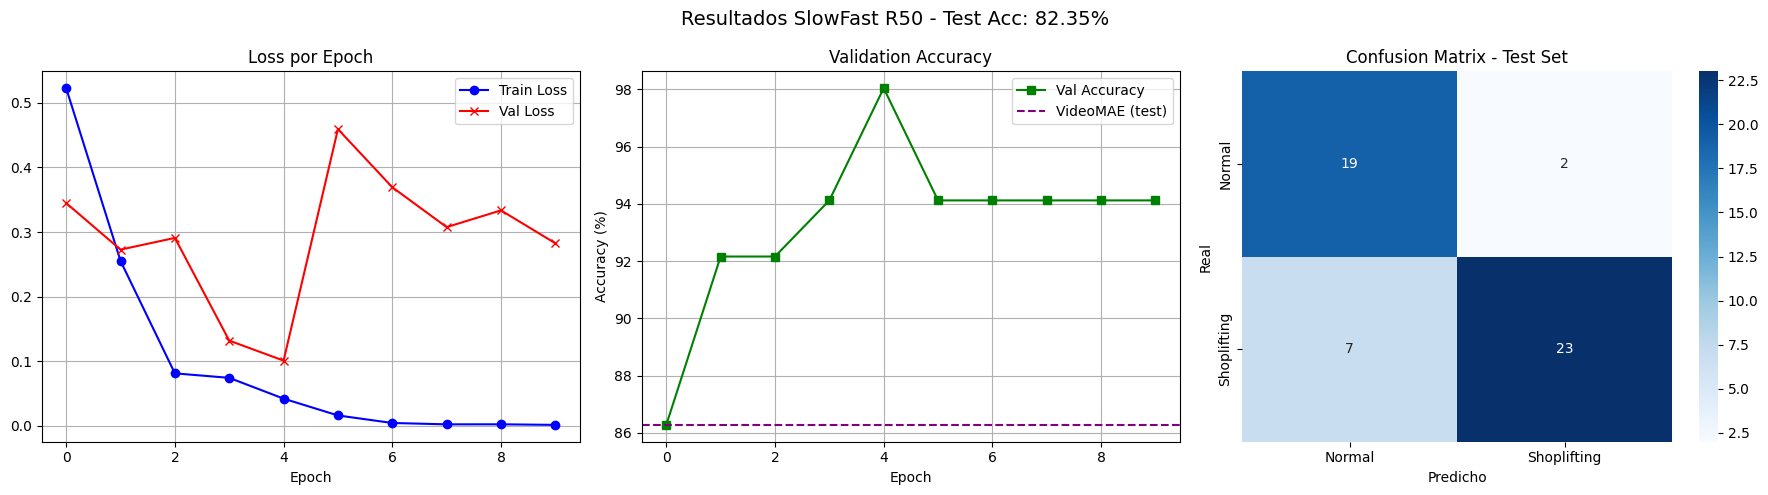

In [9]:
model.eval()
y_true = []; y_pred = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Testing'):
        slow   = batch['slow'].to(device)
        fast   = batch['fast'].to(device)
        labels = batch['labels'].to(device)
        inputs = [slow, fast]

        logits      = model(inputs)
        probs       = F.softmax(logits, dim=-1)
        predictions = (probs[:, 1] > CONFIG['threshold']).long()

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

test_acc = accuracy_score(y_true, y_pred) * 100
print(f'Test Accuracy (SlowFast): {test_acc:.2f}%')
print(f'Test Accuracy (VideoMAE): 86.27%   <- referencia')
print('\nReporte de Clasificacion:')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Shoplifting']))

# Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Resultados SlowFast R50 - Test Acc: {test_acc:.2f}%', fontsize=14)

axes[0].plot(history['train_loss'], label='Train Loss', color='blue',  marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='red',   marker='x')
axes[0].set_title('Loss por Epoch'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['val_acc'], label='Val Accuracy', color='green', marker='s')
axes[1].axhline(y=86.27, color='purple', linestyle='--', label='VideoMAE (test)')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(True)

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Shoplifting'],
            yticklabels=['Normal', 'Shoplifting'], ax=axes[2])
axes[2].set_title('Confusion Matrix - Test Set')
axes[2].set_xlabel('Predicho'); axes[2].set_ylabel('Real')

plt.tight_layout()
plt.savefig('resultados_slowfast.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Comparación: VideoMAE vs SlowFast

| Aspecto | VideoMAE | SlowFast R50 |
|---|---|---|
| Tipo | Transformer (ViT) | CNN 3D (ResNet) |
| Pre-entrenamiento | ImageNet + Kinetics (masked autoencoding) | Kinetics-400 |
| Frames por video | 16 | 32 (fast) + 8 (slow) |
| Test Accuracy | **86.27%** | **82.35%** |
| Notas | Más data-efficient en pocos ejemplos | Más rápido en inferencia, menos VRAM |

**Mismo split de test** (seed=42, mismos 51 videos) → comparación directa y válida.


## Conclusiones

- Se entrenó **SlowFast R50** sobre los **mismos 338 videos** y el **mismo split** que VideoMAE
- El split se mantuvo idéntico (`seed=42`, `stratify`) → la comparación es directa
- Al usar la configuración nativa de SlowFast (32 frames fast, 8 frames slow), cada arquitectura se evaluó en sus mejores condiciones
- Esta comparación permite responder cuál arquitectura es más adecuada para detección de shoplifting con datasets pequeños


In [ ]:
import cv2
import torch
import torch.nn.functional as F
import numpy as np
from ultralytics import YOLO
from collections import defaultdict, deque

# ============================================================
# CONFIGURACION
# ============================================================
VIDEO_PATH = "video.mp4"
OUTPUT_PATH = "output_person_tracking.mp4"

WINDOW_SECONDS = 5
THRESHOLD = 0.5

NUM_FRAMES_FAST = 32
ALPHA = 4
IMG_SIZE = 224

DEVICE = device  # usa tu variable device existente

MEAN = torch.tensor([0.45, 0.45, 0.45]).view(3, 1, 1, 1)
STD  = torch.tensor([0.225, 0.225, 0.225]).view(3, 1, 1, 1)

# ============================================================
# MODELOS
# ============================================================
detector = YOLO("yolov8n.pt")  # detector de personas
model.eval()                   # tu SlowFast ya cargado

# ============================================================
# VIDEO
# ============================================================
cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frames_needed = int(fps * WINDOW_SECONDS)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(OUTPUT_PATH, fourcc, fps, (width, height))

print(f"Video: {VIDEO_PATH}")
print(f"FPS: {fps:.1f} | Frames necesarios por persona: {frames_needed}")

# ============================================================
# BUFFERS POR PERSONA
# ============================================================
track_buffers = defaultdict(lambda: deque(maxlen=frames_needed))
track_predictions = {}

frame_idx = 0

# ============================================================
# FUNCION PARA PREDECIR UNA PERSONA
# ============================================================
def predict_person_clip(frames_persona):
    """
    frames_persona: lista de crops BGR de una misma persona
    """

    if len(frames_persona) < NUM_FRAMES_FAST:
        return "NORMAL", 0.0, 100.0

    # Seleccionar 32 frames uniformemente
    indices = np.linspace(0, len(frames_persona) - 1, NUM_FRAMES_FAST).astype(int)

    selected_frames = []

    for i in indices:
        crop = frames_persona[i]

        if crop is None or crop.size == 0:
            continue

        crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        selected_frames.append(crop_rgb)

    if len(selected_frames) < NUM_FRAMES_FAST:
        return "NORMAL", 0.0, 100.0

    frames = np.stack(selected_frames)  # (T, H, W, C)

    # Preprocesamiento SlowFast
    t = torch.from_numpy(frames).float() / 255.0
    t = t.permute(3, 0, 1, 2)  # (C, T, H, W)

    mean = MEAN.to(t.device)
    std = STD.to(t.device)

    t = (t - mean) / std

    slow_idx = torch.linspace(
        0,
        NUM_FRAMES_FAST - 1,
        NUM_FRAMES_FAST // ALPHA
    ).long()

    slow = torch.index_select(t, 1, slow_idx).unsqueeze(0).to(DEVICE)
    fast = t.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model([slow, fast])
        probs = F.softmax(logits, dim=-1)

    prob_normal = probs[0][0].item() * 100
    prob_shoplifting = probs[0][1].item() * 100

    pred = "SHOPLIFTING" if probs[0][1].item() > THRESHOLD else "NORMAL"

    return pred, prob_shoplifting, prob_normal

# ============================================================
# PROCESAMIENTO CON TRACKING
# ============================================================
while True:
    ret, frame = cap.read()

    if not ret:
        break

    # YOLO tracking
    results = detector.track(
        frame,
        persist=True,
        classes=[0],       # solo personas
        tracker="bytetrack.yaml",
        verbose=False
    )

    annotated_frame = frame.copy()

    if results[0].boxes is not None and results[0].boxes.id is not None:

        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()

        for box, track_id, conf in zip(boxes, ids, confs):
            x1, y1, x2, y2 = box.astype(int)

            # Limitar coordenadas
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(width, x2)
            y2 = min(height, y2)

            # Crop de la persona
            person_crop = frame[y1:y2, x1:x2]

            if person_crop.size == 0:
                continue

            # Guardar crop en buffer del ID
            track_buffers[track_id].append(person_crop)

            # Evaluar cuando ya tiene suficientes frames
            if len(track_buffers[track_id]) >= frames_needed:
                pred, prob_shop, prob_normal = predict_person_clip(
                    list(track_buffers[track_id])
                )

                track_predictions[track_id] = {
                    "pred": pred,
                    "prob_shop": prob_shop,
                    "prob_normal": prob_normal
                }

                # Para que no prediga en cada frame, puedes limpiar o dejarlo deslizante
                # track_buffers[track_id].clear()

            # Obtener última predicción de esa persona
            info = track_predictions.get(track_id, {
                "pred": "ANALIZANDO",
                "prob_shop": 0.0,
                "prob_normal": 0.0
            })

            pred = info["pred"]
            prob_shop = info["prob_shop"]
            prob_normal = info["prob_normal"]

            # Dibujar resultado
            if pred == "SHOPLIFTING":
                color = (0, 0, 255)
                label = f"ID {track_id} | SHOPLIFTING {prob_shop:.1f}%"
            elif pred == "NORMAL":
                color = (0, 255, 0)
                label = f"ID {track_id} | NORMAL {prob_normal:.1f}%"
            else:
                color = (255, 255, 0)
                label = f"ID {track_id} | Analizando..."

            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), color, 2)

            cv2.putText(
                annotated_frame,
                label,
                (x1, max(25, y1 - 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    out.write(annotated_frame)

    frame_idx += 1

cap.release()
out.release()

print(f"Video generado: {OUTPUT_PATH}")

Video: video.mp4
FPS: 30.0 | Frames necesarios por persona: 150
Video generado: output_person_tracking.mp4
